In [1]:
# CREATE TASK 1 NOTEBOOK AND RUN IT
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import joblib
import pandas as pd
import numpy as np

print("="*50)
print("INTERNSPARK - TASK 1: ML CLASSIFICATION")
print("="*50)

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Evaluate
y_pred = rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])

print(f"Model Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Save models
joblib.dump(rf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n✅ Models saved successfully!")
print("   - best_model.pkl")
print("   - scaler.pkl")

# Verify
import os
print(f"\nFiles created:")
print(f"  best_model.pkl: {os.path.exists('best_model.pkl')}")
print(f"  scaler.pkl: {os.path.exists('scaler.pkl')}")

INTERNSPARK - TASK 1: ML CLASSIFICATION
Dataset: 569 samples, 30 features
Model Accuracy: 0.9649
ROC-AUC Score: 0.9953

✅ Models saved successfully!
   - best_model.pkl
   - scaler.pkl

Files created:
  best_model.pkl: True
  scaler.pkl: True


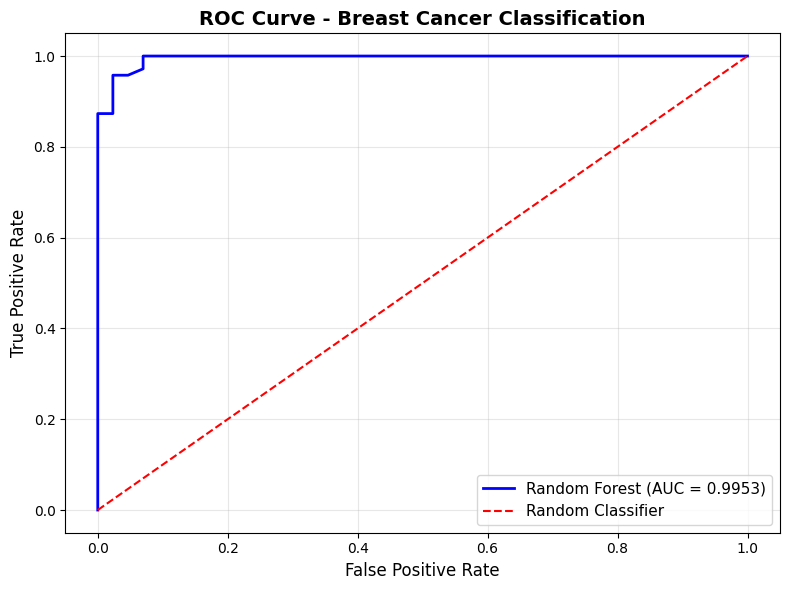


✅ ROC-AUC Score: 0.9953
   (1.0 = perfect prediction, 0.5 = random guess)


In [5]:
# CLEAN ROC CURVE - No warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import joblib
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load your saved model
rf = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')

# Get test data as DataFrame (to keep feature names)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale using DataFrame (preserves feature names)
X_test_scaled = scaler.transform(X_test)

# Get predictions
y_proba = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Breast Cancer Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ ROC-AUC Score: {auc:.4f}")
print("   (1.0 = perfect prediction, 0.5 = random guess)")

In [2]:
import os

print("Checking for model files:")
print(f"best_model.pkl: {'✅ EXISTS' if os.path.exists('best_model.pkl') else '❌ NOT FOUND'}")
print(f"scaler.pkl: {'✅ EXISTS' if os.path.exists('scaler.pkl') else '❌ NOT FOUND'}")

# List all .pkl files
pkl_files = [f for f in os.listdir('.') if f.endswith('.pkl')]
print(f"\nAll .pkl files: {pkl_files}")

Checking for model files:
best_model.pkl: ✅ EXISTS
scaler.pkl: ✅ EXISTS

All .pkl files: ['best_model.pkl', 'scaler.pkl']


In [3]:
import requests
import json

print("🚀 Testing InternSpark API...")
print("="*40)

# Sample breast cancer data (Malignant case)
sample_features = [
    17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
    1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
    25.38, 17.33, 184.6, 2019.0, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189
]

try:
    # Send request to API
    response = requests.post(
        'http://localhost:5000/predict',
        json={'features': sample_features},
        timeout=5
    )
    
    if response.status_code == 200:
        print("\n✅ API IS WORKING!\n")
        result = response.json()
        print("📊 Prediction Result:")
        print(f"   Tumor Type: {result['tumor_type']}")
        print(f"   Confidence: {result['confidence']:.2%}")
        print(f"\n📋 Full Response:")
        print(json.dumps(result, indent=2))
    else:
        print(f"❌ Error: {response.status_code}")
        
except requests.exceptions.ConnectionError:
    print("\n❌ Cannot connect to API!")
    print("Make sure the terminal with 'python app.py' is still running")
    
except Exception as e:
    print(f"\n❌ Error: {e}")

🚀 Testing InternSpark API...

✅ API IS WORKING!

📊 Prediction Result:
   Tumor Type: Malignant
   Confidence: 96.00%

📋 Full Response:
{
  "confidence": 0.96,
  "prediction": 0,
  "probabilities": {
    "benign": 0.04,
    "malignant": 0.96
  },
  "tumor_type": "Malignant"
}


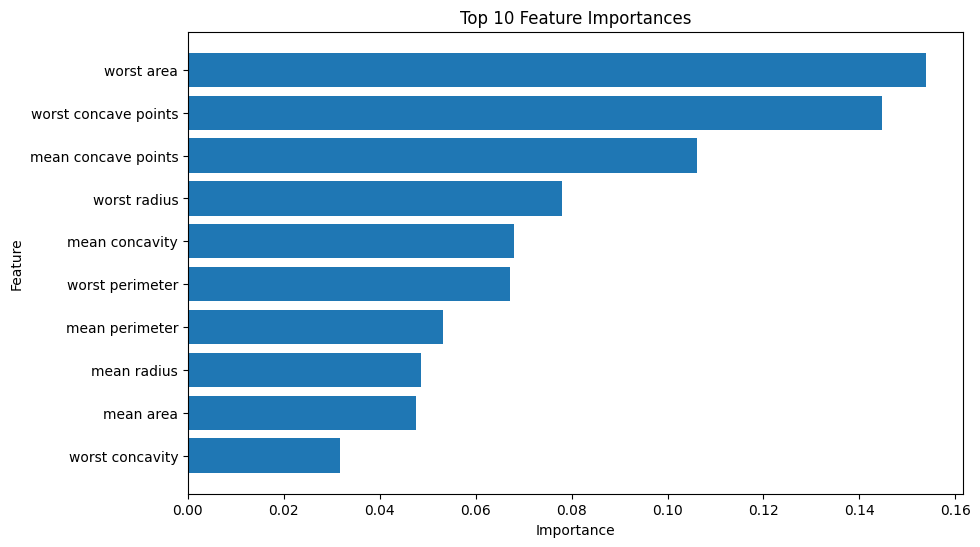

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 10 features
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()